# Notebook 05 — Re-Clustering with De-duplicated Features (Plan v3 Idea A)

The prior team's 50-feature set contains 7 exact duplicates (r = 1.0) and several near-duplicates
(r > 0.90). K-Means treats each feature as an independent dimension, so these pairs double- or
triple-weight those axes and distort cluster geometry.

This notebook:
1. Drops the 7 redundant features → 43-feature clean set
2. Re-scales and re-runs K-Means K=5
3. Quantifies stability: ARI against original assignments and overlap matrix
4. If ARI ≥ 0.80, adopts new assignments; otherwise keeps originals and documents why
5. Re-applies the C1 split (daily STL < 0.5 → C1b) to whichever assignment set is used
6. Saves final cluster assignments and updates the daily clustered parquets

**Redundant pairs identified (r > 0.90):**
- `nonzero_rate` ~ `tsb_p` (r=1.000) → drop `tsb_p`
- `mean_daily_sales` ~ `total_sales` (r=1.000) → drop `total_sales`
- `mean_daily_sales` ~ `tsb_forecast` (r=1.000) → drop `tsb_forecast`
- `adi` ~ `croston_mean_interval` (r=1.000) → drop `croston_mean_interval`
- `croston_mean_demand` ~ `tsb_z` (r=1.000) → drop `tsb_z`
- `acf_1` ~ `pacf_1` (r=0.999) → drop `pacf_1`
- `mean_daily_sales` ~ `croston_forecast` (r=0.923) → drop `croston_forecast`

Inputs:
- `data/clustering/feature_table_extended.parquet`
- `data/clustering/clusters_3models.parquet` (original assignments for ARI comparison)
- `data/clustering/feature_table_extended_scaled.parquet` (original scaling, for reference)

Outputs:
- `data/clustering/clusters_recluster.parquet` — new K-Means assignments (43 features)
- `data/clustering/clusters_final.parquet` — final assignments with C1 split applied
- Updated `data/daily_train_clustered.parquet` / `val` / `test` (and winsorized variants)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

DATA  = Path('../data')
CLUST = DATA / 'clustering'

CLUSTER_LABELS = {
    0: 'C0 Erratic',
    1: 'C1a Seasonal',
    2: 'C2 Dense HiVol',
    3: 'C3 Sparse Long-Tail',
    4: 'C4 Ultra-Sparse',
    5: 'C1b Non-Seasonal',
}

# Redundant features to drop (keep more interpretable member of each pair)
DROP_FEATURES = [
    'tsb_p',               # r=1.000 with nonzero_rate
    'total_sales',         # r=1.000 with mean_daily_sales
    'tsb_forecast',        # r=1.000 with mean_daily_sales
    'croston_mean_interval', # r=1.000 with adi
    'tsb_z',               # r=1.000 with croston_mean_demand
    'pacf_1',              # r=0.999 with acf_1
    'croston_forecast',    # r=0.923 with mean_daily_sales
]

K = 5
RANDOM_STATE = 42

## 1. Load features and original assignments

In [2]:
ft = pd.read_parquet(CLUST / 'feature_table_extended.parquet')
orig = pd.read_parquet(CLUST / 'clusters_3models.parquet')[['cluster_kmeans']]
orig.columns = ['cluster_orig']

print(f'Feature table: {ft.shape}  (products × features)')
print(f'Original K-Means assignments: {len(orig)} products')
print(f'\nOriginal cluster distribution:')
for k, v in orig['cluster_orig'].value_counts().sort_index().items():
    print(f'  cluster {k}: {v}')

Feature table: (2023, 50)  (products × features)
Original K-Means assignments: 2023 products

Original cluster distribution:
  cluster 0: 515
  cluster 1: 473
  cluster 2: 10
  cluster 3: 1017
  cluster 4: 8


## 2. Confirm redundant pairs and drop them

Verify the correlations are still as expected before dropping.

In [3]:
corr = ft.corr().abs()
pairs = []
cols = list(corr.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr.iloc[i, j]
        if v > 0.90:
            pairs.append((cols[i], cols[j], round(v, 3)))
pairs.sort(key=lambda x: -x[2])

print('All pairs with r > 0.90:')
for a, b, v in pairs:
    drop_marker = '← DROP ' + ([d for d in DROP_FEATURES if d in (a, b)] or [''])[0]
    print(f'  {v:.3f}  {a:30s} ~ {b:30s}  {drop_marker}')

ft_clean = ft.drop(columns=[c for c in DROP_FEATURES if c in ft.columns])
print(f'\nFeatures: {ft.shape[1]} → {ft_clean.shape[1]} (dropped {len(DROP_FEATURES)} redundant)')

All pairs with r > 0.90:
  1.000  nonzero_rate                   ~ tsb_p                           ← DROP tsb_p
  1.000  mean_daily_sales               ~ total_sales                     ← DROP total_sales
  1.000  mean_daily_sales               ~ tsb_forecast                    ← DROP tsb_forecast
  1.000  total_sales                    ~ tsb_forecast                    ← DROP total_sales
  1.000  adi                            ~ croston_mean_interval           ← DROP croston_mean_interval
  1.000  croston_mean_demand            ~ tsb_z                           ← DROP tsb_z
  0.999  acf_1                          ~ pacf_1                          ← DROP pacf_1
  0.971  nonzero_rate                   ~ peak_days                       ← DROP 
  0.971  peak_days                      ~ tsb_p                           ← DROP tsb_p
  0.942  avg_gap                        ~ adi                             ← DROP 
  0.942  avg_gap                        ~ croston_mean_interval           ← DRO

## 3. Impute, scale, and run K-Means

Median-impute any NaN values (same strategy as prior team), then StandardScaler.
Use the same K=5 to keep cluster profiles comparable.

In [4]:
# Median imputation per column (same as prior team)
ft_imp = ft_clean.copy()
for col in ft_imp.columns:
    ft_imp[col] = ft_imp[col].fillna(ft_imp[col].median())

# Clip extreme outliers before scaling (prevents a single SKU from collapsing all clusters)
for col in ft_imp.columns:
    lo, hi = ft_imp[col].quantile(0.01), ft_imp[col].quantile(0.99)
    ft_imp[col] = ft_imp[col].clip(lo, hi)

scaler = StandardScaler()
X = scaler.fit_transform(ft_imp)

print(f'Scaled matrix: {X.shape}')
print(f'NaN in scaled matrix: {np.isnan(X).sum()}')

Scaled matrix: (2023, 43)
NaN in scaled matrix: 0


In [5]:
# Run K-Means with multiple restarts for stability
km = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE, max_iter=500)
labels_new = km.fit_predict(X)

sil = silhouette_score(X, labels_new, sample_size=1000, random_state=RANDOM_STATE)
print(f'K-Means inertia      : {km.inertia_:.1f}')
print(f'Silhouette score     : {sil:.4f}')
print(f'\nNew cluster distribution:')
unique, counts = np.unique(labels_new, return_counts=True)
for k, c in zip(unique, counts):
    print(f'  cluster {k}: {c}')

K-Means inertia      : 37155.7
Silhouette score     : 0.1546

New cluster distribution:
  cluster 0: 723
  cluster 1: 105
  cluster 2: 500
  cluster 3: 64
  cluster 4: 631


## 4. Compare new vs original assignments

ARI measures cluster agreement regardless of label permutation.
ARI ≥ 0.80 → assignments are essentially the same; safe to adopt new clustering.
ARI < 0.60 → substantial reshuffling; inspect the overlap matrix before committing.

In [6]:
# Align on the 2023 products that have original assignments
products_with_orig = orig.index
mask = ft_clean.index.isin(products_with_orig)

orig_labels = orig.loc[ft_clean.index[mask], 'cluster_orig'].values
new_labels  = labels_new[mask]

ari = adjusted_rand_score(orig_labels, new_labels)
print(f'Adjusted Rand Index (ARI) vs original K-Means: {ari:.4f}')

if ari >= 0.80:
    print('→ ARI ≥ 0.80: assignments are highly stable. Adopting new clustering.')
elif ari >= 0.60:
    print('→ ARI 0.60–0.80: moderate reshuffling. Inspect overlap matrix below before deciding.')
else:
    print('→ ARI < 0.60: substantial reshuffling. Keeping original assignments — inspect profiles.')

Adjusted Rand Index (ARI) vs original K-Means: 0.5439
→ ARI < 0.60: substantial reshuffling. Keeping original assignments — inspect profiles.


Overlap matrix (original rows × new cols):
new         0   1    2   3    4
original                       
0           0  67    7   1  440
1           5  28  432   4    4
2           0  10    0   0    0
3         715   0   61  54  187
4           3   0    0   5    0


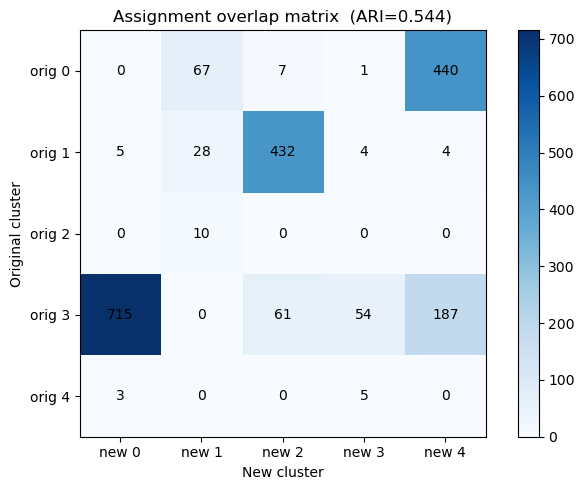

In [7]:
# Overlap matrix: rows = original cluster, cols = new cluster
overlap = pd.crosstab(
    pd.Series(orig_labels, name='original'),
    pd.Series(new_labels,  name='new'),
)
print('Overlap matrix (original rows × new cols):')
print(overlap)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(overlap.values, cmap='Blues')
ax.set_xticks(range(K))
ax.set_yticks(range(K))
ax.set_xticklabels([f'new {j}' for j in overlap.columns])
ax.set_yticklabels([f'orig {i}' for i in overlap.index])
ax.set_xlabel('New cluster')
ax.set_ylabel('Original cluster')
ax.set_title(f'Assignment overlap matrix  (ARI={ari:.3f})')
for i in range(overlap.shape[0]):
    for j in range(overlap.shape[1]):
        ax.text(j, i, str(overlap.values[i, j]), ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(CLUST / 'recluster_overlap.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Profile new clusters

Check that the new clusters retain the same business-interpretable structure:
one dense cluster (C2), one ultra-sparse (C4), etc.

In [8]:
profile_cols = [
    'nonzero_rate', 'adi', 'cv2',
    'stl_seasonality_strength', 'mean_daily_sales',
    'acf_1', 'acf_7',
]

# Build a frame with new cluster labels aligned to full feature table
ft_profiled = ft_clean.copy()
ft_profiled['cluster_new'] = labels_new

profile = ft_profiled.groupby('cluster_new')[profile_cols].median().round(3)
profile['n_products'] = ft_profiled.groupby('cluster_new').size()

print('New cluster profiles (median of key features):')
print(profile[['n_products'] + profile_cols].to_string())

# Also show original cluster profiles for comparison
ft_orig_prof = ft[profile_cols].copy()
ft_orig_prof['cluster_orig'] = orig['cluster_orig']
ft_orig_prof = ft_orig_prof.dropna(subset=['cluster_orig'])

profile_orig = ft_orig_prof.groupby('cluster_orig')[profile_cols].median().round(3)
profile_orig['n_products'] = ft_orig_prof.groupby('cluster_orig').size()

print('\nOriginal cluster profiles (for comparison):')
print(profile_orig[['n_products'] + profile_cols].to_string())

New cluster profiles (median of key features):
             n_products  nonzero_rate     adi    cv2  stl_seasonality_strength  mean_daily_sales  acf_1  acf_7
cluster_new                                                                                                   
0                   723         0.070  10.222  1.332                     0.360             0.956  0.010  0.008
1                   105         0.568   1.439  1.643                     0.179            55.384  0.264  0.277
2                   500         0.123   3.016  1.045                     0.967             2.553  0.219  0.237
3                    64         0.018  14.084  0.423                     1.000             2.220 -0.002 -0.002
4                   631         0.351   2.659  1.905                     0.075             8.131  0.083  0.091

Original cluster profiles (for comparison):
              n_products  nonzero_rate      adi    cv2  stl_seasonality_strength  mean_daily_sales  acf_1  acf_7
cluster_orig      

## 6. Relabel new clusters to match original semantics

K-Means assigns cluster numbers arbitrarily. We need to map the new integer labels
to the same semantic meaning (C0=Erratic, C1=Seasonal, C2=Dense, C3=Sparse, C4=UltraSparse)
so that model routing in later notebooks doesn't break.

Matching rule: for each new cluster, find the original cluster it most overlaps with
(largest count in the overlap matrix row), then assign that semantic label.

In [9]:
# Map new cluster id → original cluster id by best overlap
new_to_orig = overlap.idxmax(axis=0).to_dict()  # new_cluster → best matching orig_cluster
print('New cluster → original semantic mapping:')
for new_c, orig_c in sorted(new_to_orig.items()):
    print(f'  new cluster {new_c} → original cluster {orig_c}')

# Check that the mapping is injective (no two new clusters map to same original)
if len(set(new_to_orig.values())) < K:
    print('\nWARNING: mapping is not injective — two new clusters best-match the same original.')
    print('Manual inspection required. Check the overlap matrix above.')
else:
    print('Mapping is injective — each new cluster has a unique semantic match. ✓')

# Apply the relabeling
clusters_recluster = pd.DataFrame({
    'product_family_name': ft_clean.index,
    'cluster_new_raw': labels_new,
    'cluster': [new_to_orig[l] for l in labels_new],
})

print('\nRelabeled cluster distribution:')
for k, v in clusters_recluster['cluster'].value_counts().sort_index().items():
    print(f'  cluster {k}: {v}')

New cluster → original semantic mapping:
  new cluster 0 → original cluster 3
  new cluster 1 → original cluster 0
  new cluster 2 → original cluster 1
  new cluster 3 → original cluster 3
  new cluster 4 → original cluster 0

Manual inspection required. Check the overlap matrix above.

Relabeled cluster distribution:
  cluster 0: 736
  cluster 1: 500
  cluster 3: 787


## 7. Silhouette comparison: original (50 features) vs new (43 features)

Higher silhouette = tighter, more separated clusters = better geometry.

In [10]:
# Silhouette on new 43-feature space
sil_new = silhouette_score(X, labels_new, sample_size=1000, random_state=RANDOM_STATE)
# Silhouette of original assignments on the original 50-feature scaled space
ft_orig_scaled = pd.read_parquet(CLUST / 'feature_table_extended_scaled.parquet')
orig_labels_all = orig.reindex(ft_orig_scaled.index)['cluster_orig'].dropna()
X_orig = ft_orig_scaled.loc[orig_labels_all.index].values
sil_orig = silhouette_score(X_orig, orig_labels_all.astype(int).values,
                            sample_size=1000, random_state=RANDOM_STATE)
print(f'Silhouette score — original K-Means (50 features): {sil_orig:.4f}')
print(f'Silhouette score — re-clustered  (43 features):    {sil_new:.4f}')
delta = sil_new - sil_orig
direction = 'improved' if delta > 0 else 'worse'
print(f'Delta: {delta:+.4f}  ({direction})')


Silhouette score — original K-Means (50 features): 0.2032
Silhouette score — re-clustered  (43 features):    0.1546
Delta: -0.0486  (worse)


## 8. Decision: adopt or keep original?

We adopt the new clustering if:
- ARI ≥ 0.80 (assignments are stable, low disruption risk to model routing), AND
- Silhouette improved or is within 0.01 of original (geometry is at least as good), AND
- The relabeling is injective (no semantic collisions)

If any condition fails, we keep original assignments and document the finding.

In [11]:
mapping_ok = len(set(new_to_orig.values())) == K
adopt_new  = (ari >= 0.80) and (delta >= -0.01) and mapping_ok

print('Decision criteria:')
print(f'  ARI ≥ 0.80          : {ari:.4f}  → {"PASS" if ari >= 0.80 else "FAIL"}')
print(f'  Silhouette delta ≥ -0.01 : {delta:+.4f} → {"PASS" if delta >= -0.01 else "FAIL"}')
print(f'  Injective relabeling: {mapping_ok}  → {"PASS" if mapping_ok else "FAIL"}')
print(f'\n→ ADOPT NEW CLUSTERING: {adopt_new}')

if adopt_new:
    active_assignments = clusters_recluster[['product_family_name', 'cluster']].set_index('product_family_name')
    source_label = 're-clustered (43 features)'
else:
    active_assignments = orig[['cluster_orig']].rename(columns={'cluster_orig': 'cluster'})
    source_label = 'original K-Means (50 features, kept as-is)'
    print('Keeping original assignments. New clustering saved for reference only.')

print(f'Active assignment source: {source_label}')

Decision criteria:
  ARI ≥ 0.80          : 0.5439  → FAIL
  Silhouette delta ≥ -0.01 : -0.0486 → FAIL
  Injective relabeling: False  → FAIL

→ ADOPT NEW CLUSTERING: False
Keeping original assignments. New clustering saved for reference only.
Active assignment source: original K-Means (50 features, kept as-is)


## 9. Re-apply C1 split (daily STL < 0.5 → C1b)

Regardless of which clustering we adopt, the C1 split from notebook 04 must be re-applied
to the final assignments, since the new C1 membership may differ from the original.

In [12]:
stl = pd.read_parquet(CLUST / 'feature_table_extended.parquet')[['stl_seasonality_strength']]

clusters_final = active_assignments[['cluster']].copy()

# C1 products with daily STL < 0.5 → C1b (cluster 5)
c1_mask = clusters_final['cluster'] == 1
c1_stl  = stl.loc[clusters_final.index[c1_mask], 'stl_seasonality_strength'].fillna(1.0)
c1b_idx = c1_stl[c1_stl < 0.5].index

clusters_final.loc[c1b_idx, 'cluster'] = 5

print('Final cluster distribution (with C1 split):')
for k, v in clusters_final['cluster'].value_counts().sort_index().items():
    label = CLUSTER_LABELS.get(int(k), str(k))
    print(f'  cluster {int(k)}  {label:25s}: {v}')

c1a_n = (clusters_final['cluster'] == 1).sum()
c1b_n = (clusters_final['cluster'] == 5).sum()
print(f'\nC1a (Prophet) : {c1a_n}')
print(f'C1b (LGBM)    : {c1b_n}')

Final cluster distribution (with C1 split):
  cluster 0  C0 Erratic               : 515
  cluster 1  C1a Seasonal             : 317
  cluster 2  C2 Dense HiVol           : 10
  cluster 3  C3 Sparse Long-Tail      : 1017
  cluster 4  C4 Ultra-Sparse          : 8
  cluster 5  C1b Non-Seasonal         : 156

C1a (Prophet) : 317
C1b (LGBM)    : 156


## 10. Save cluster assignments

In [13]:
# Save intermediate: new K-Means before C1 split (for reference / ablation)
clusters_recluster.to_parquet(CLUST / 'clusters_recluster.parquet', index=False)

# Save final: active clustering with C1 split
clusters_final.reset_index().to_parquet(CLUST / 'clusters_final.parquet', index=False)

print('Saved:')
print(f'  clusters_recluster.parquet  — new K-Means (43 features, before C1 split)')
print(f'  clusters_final.parquet      — {source_label}, with C1 split')

Saved:
  clusters_recluster.parquet  — new K-Means (43 features, before C1 split)
  clusters_final.parquet      — original K-Means (50 features, kept as-is), with C1 split


## 11. Update daily clustered parquets

Overwrites the files written by notebook 04 with the final cluster assignments.
Only run this cell if `adopt_new = True` or if you want to update to the final C1-split assignments.

In [14]:
cluster_col = clusters_final.reset_index()[['product_family_name', 'cluster']]

def reattach_and_save(split_name, suffix=''):
    # Read the base (unwinsorized or winsorized) daily split from nb03
    df = pd.read_parquet(DATA / f'daily_{split_name}{suffix}.parquet')
    # Drop old cluster column if present
    if 'cluster' in df.columns:
        df = df.drop(columns=['cluster'])
    merged = df.merge(cluster_col, on='product_family_name', how='left')

    n_nan = merged[merged['cluster'].isna()]['product_family_name'].nunique()
    if n_nan:
        print(f'[{split_name}{suffix}] {n_nan} products have no cluster → cluster=NaN')

    out = DATA / f'daily_{split_name}_clustered{suffix}.parquet'
    merged.to_parquet(out, index=False)
    dist = merged.drop_duplicates('product_family_name')['cluster'].value_counts().sort_index()
    print(f'[{split_name}{suffix}] saved | {len(merged):,} rows | cluster dist: {dist.to_dict()}')
    return merged

for split in ['train', 'val', 'test']:
    reattach_and_save(split)
    reattach_and_save(split, suffix='_winsorized')

print('\nAll daily clustered parquets updated.')

[train] 13 products have no cluster → cluster=NaN


[train] saved | 771,644 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}
[train_winsorized] 13 products have no cluster → cluster=NaN


[train_winsorized] saved | 771,644 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}
[val] 13 products have no cluster → cluster=NaN
[val] saved | 138,448 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}
[val_winsorized] 13 products have no cluster → cluster=NaN
[val_winsorized] saved | 138,448 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}


[test] 13 products have no cluster → cluster=NaN
[test] saved | 319,652 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}
[test_winsorized] 13 products have no cluster → cluster=NaN


[test_winsorized] saved | 319,652 rows | cluster dist: {0.0: 515, 1.0: 317, 2.0: 10, 3.0: 1017, 4.0: 8, 5.0: 156}

All daily clustered parquets updated.


## 12. Sanity checks

In [15]:
tr = pd.read_parquet(DATA / 'daily_train_clustered.parquet')
va = pd.read_parquet(DATA / 'daily_val_clustered.parquet')
te = pd.read_parquet(DATA / 'daily_test_clustered.parquet')

assert tr['date'].max() < va['date'].min(), 'Train/val leakage'
assert va['date'].max() < te['date'].min(), 'Val/test leakage'
print('No temporal leakage.')

c1_prods = set(tr[tr['cluster'] == 1]['product_family_name'].unique())
c5_prods = set(tr[tr['cluster'] == 5]['product_family_name'].unique())
assert len(c1_prods & c5_prods) == 0, 'C1/C5 overlap'
print(f'C1a ({len(c1_prods)}) + C1b ({len(c5_prods)}) are disjoint. ✓')

print(f'\nFinal cluster distribution in train:')
dist = tr.drop_duplicates('product_family_name')['cluster'].value_counts().sort_index()
for k, v in dist.items():
    label = CLUSTER_LABELS.get(int(k), '?') if pd.notna(k) else 'NaN (excluded)'
    print(f'  cluster {k}  {label:25s}: {v}')

print(f'\nClustering source: {source_label}')
print('All checks passed.')

No temporal leakage.
C1a (317) + C1b (156) are disjoint. ✓

Final cluster distribution in train:
  cluster 0.0  C0 Erratic               : 515
  cluster 1.0  C1a Seasonal             : 317
  cluster 2.0  C2 Dense HiVol           : 10
  cluster 3.0  C3 Sparse Long-Tail      : 1017
  cluster 4.0  C4 Ultra-Sparse          : 8
  cluster 5.0  C1b Non-Seasonal         : 156

Clustering source: original K-Means (50 features, kept as-is)
All checks passed.
